# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/House_Rent_Dataset.csv')

In [3]:
df.shape

(4746, 12)

In [4]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


1. Аналіз пропущених значень

In [6]:
# Перевіряємо кількість пропусків у кожній колонці
missing_values = df.isnull().sum()

# Рахуємо відсоток пропусків
missing_percent = (missing_values / len(df)) * 100

# Об'єднуємо в одну таблицю
missing_df = pd.DataFrame({
    'Кількість пропусків': missing_values,
    'Відсоток (%)': missing_percent
})

missing_df

,Кількість пропусків,Відсоток (%)
Posted On,0,0.0
BHK,0,0.0
Rent,0,0.0
Size,0,0.0
Floor,0,0.0
Area Type,0,0.0
Area Locality,0,0.0
City,0,0.0
Furnishing Status,0,0.0
Tenant Preferred,0,0.0


У датасеті відсутні пропущені значення.

2. Базова статистика. Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.

In [7]:
# Обираємо числові колонки
numeric_cols = ['BHK', 'Rent', 'Size', 'Bathroom']

# Обчислюємо базову статистику
stats = df[numeric_cols].describe()

# Округлюємо для зручності
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


3. Аналіз цільової змінної. Побудуйте гістограму розподілу цільової змінної (Rent)

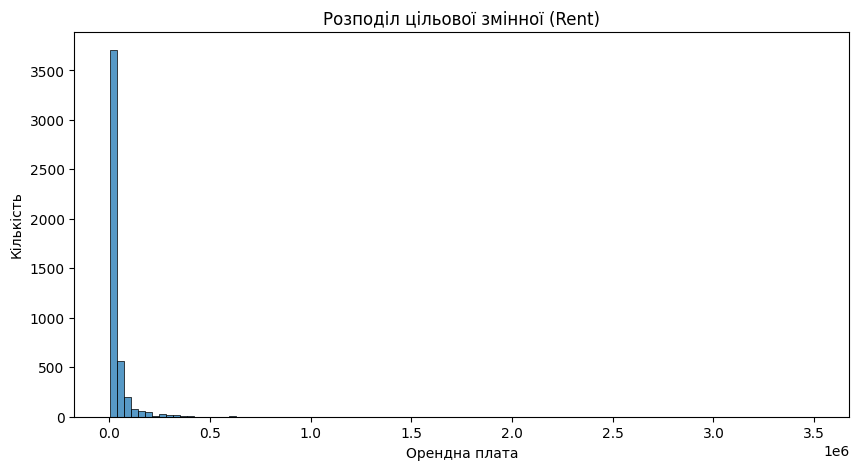

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['Rent'], bins=100)

plt.title('Розподіл цільової змінної (Rent)')
plt.xlabel('Орендна плата')
plt.ylabel('Кількість')

plt.show()

Розподіл змінної Rent є сильно скошеним вправо.
Більшість значень знаходиться в нижньому діапазоні,
але присутні дуже великі значення, які формують довгий хвіст.

Це свідчить про наявність викидів та нерівномірний розподіл даних.

In [9]:
import numpy as np

df['log_rent'] = np.log1p(df['Rent'])

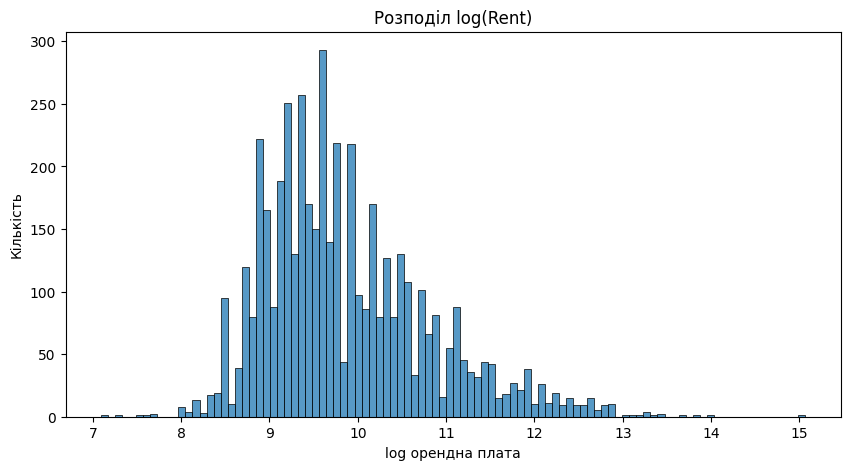

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['log_rent'], bins=100)

plt.title('Розподіл log(Rent)')
plt.xlabel('log орендна плата')
plt.ylabel('Кількість')

plt.show()

Розподіл змінної Rent до перетворення є сильно скошеним вправо,
що свідчить про наявність великих значень (викидів).

Після застосування логарифмічного перетворення розподіл став більш симетричним
та наближеним до нормального.

Логарифмування дозволило зменшити вплив екстремальних значень,
що є важливим для покращення якості моделей машинного навчання.

Отже, доцільно використовувати log(Rent) як цільову змінну.

4. Робота з викидами. Знайдіть та видаліть викиди в цільовій змінній (якщо є).

In [11]:
# Обчислюємо квартилі для log_rent
Q1 = df['log_rent'].quantile(0.25)
Q3 = df['log_rent'].quantile(0.75)

# Обчислюємо міжквартильний розмах
IQR = Q3 - Q1

# Визначаємо межі для викидів
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Нижня межа:", lower_bound)
print("Верхня межа:", upper_bound)

Нижня межа: 7.419661202911604
Верхня межа: 12.195072307084706


In [12]:
# Знаходимо кількість викидів
outliers = df[(df['log_rent'] < lower_bound) | (df['log_rent'] > upper_bound)]

print("Кількість викидів:", len(outliers))

Кількість викидів: 116


In [13]:
# Видаляємо викиди
df_clean = df[(df['log_rent'] >= lower_bound) & (df['log_rent'] <= upper_bound)].copy()

print("Розмір до очищення:", df.shape)
print("Розмір після очищення:", df_clean.shape)

Розмір до очищення: (4746, 13)
Розмір після очищення: (4630, 13)


Викиди було визначено за допомогою методу міжквартильного розмаху (IQR),
який використовується в побудові box-plot.

Для більш коректного аналізу викиди визначались на логарифмованій змінній log(Rent).

Було виявлено 116 викидів, які були видалені з датасету.

Після очищення розмір вибірки зменшився з 4746 до 4630 записів.

Видалення викидів дозволяє зменшити вплив екстремальних значень
та покращити якість майбутньої моделі.

5. Аналіз категоріальних змінних. Виведіть кількість унікальних значень для кожної з категоріальних колонок.

In [14]:
# Обираємо категоріальні колонки (тип object)
categorical_cols = df.select_dtypes(include='object').columns

# Рахуємо кількість унікальних значень
unique_counts = df[categorical_cols].nunique()

unique_counts

,0
Posted On,81
Floor,480
Area Type,3
Area Locality,2235
City,6
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3


In [15]:
cat_summary = pd.DataFrame({
    'Кількість унікальних значень': df[categorical_cols].nunique()
})

cat_summary

,Кількість унікальних значень
Posted On,81
Floor,480
Area Type,3
Area Locality,2235
City,6
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3


In [16]:
cat_summary.sort_values(by='Кількість унікальних значень', ascending=False)

,Кількість унікальних значень
Area Locality,2235
Floor,480
Posted On,81
City,6
Area Type,3
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3


Було проаналізовано категоріальні змінні датасету.

Для кожної категоріальної колонки визначено кількість унікальних значень,
що дозволяє оцінити різноманітність даних.

Деякі змінні мають велику кількість унікальних значень (наприклад, Area Locality),
що може потребувати додаткової обробки (наприклад, кодування або агрегування)
при побудові моделі.

Інші змінні мають невелику кількість категорій (наприклад, Furnishing Status),
що зручно для подальшого використання в моделі.


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


1. Обчисліть матрицю кореляцій для числових змінних

In [17]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = df[numeric_cols].corr()

corr_matrix

,BHK,Rent,Size,Bathroom,log_rent
BHK,1.000000,0.369718,0.716145,0.794885,0.596346
Rent,0.369718,1.000000,0.413551,0.441215,0.635633
Size,0.716145,0.413551,1.000000,0.740703,0.567943
Bathroom,0.794885,0.441215,0.740703,1.000000,0.692095
log_rent,0.596346,0.635633,0.567943,0.692095,1.000000


2. Візуалізуйте кореляційну матрицю за допомогою heatmap

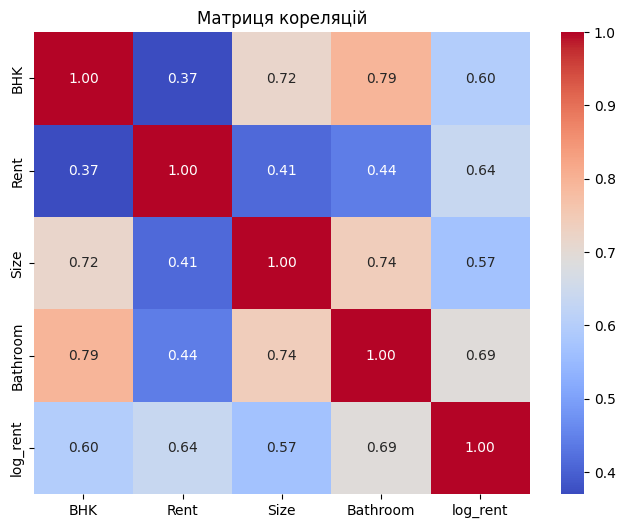

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Матриця кореляцій')
plt.show()

Матриця кореляцій показує, що між змінними існують помітні позитивні зв’язки.

Найсильніші кореляції спостерігаються між:
- BHK та Bathroom (0.79)
- Size та Bathroom (0.74)
- BHK та Size (0.72)

Цільова змінна log(Rent) має помірну кореляцію з усіма числовими ознаками,
зокрема з Bathroom (0.69), Rent (0.64) та BHK (0.60).

Це свідчить про те, що ці змінні впливають на орендну плату
та можуть бути використані при побудові моделі.

3. Побудуйте scatter plot між Size та Rent

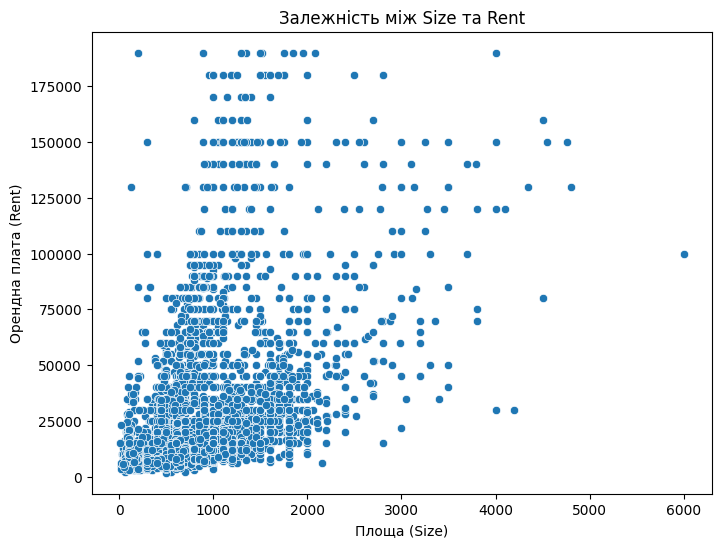

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_clean['Size'],
    y=df_clean['Rent']
)

plt.title('Залежність між Size та Rent')
plt.xlabel('Площа (Size)')
plt.ylabel('Орендна плата (Rent)')

plt.show()

Було побудовано scatter plot для аналізу залежності між площею житла (Size)
та орендною платою (Rent).

Спостерігається позитивна залежність:
зі збільшенням площі житла орендна плата загалом зростає.

Водночас точки мають значний розкид,
що свідчить про вплив інших факторів на ціну,
таких як місто, район, стан житла тощо.

Залежність не є строго лінійною, що означає,
що лише площі недостатньо для точного прогнозування орендної плати.

4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)

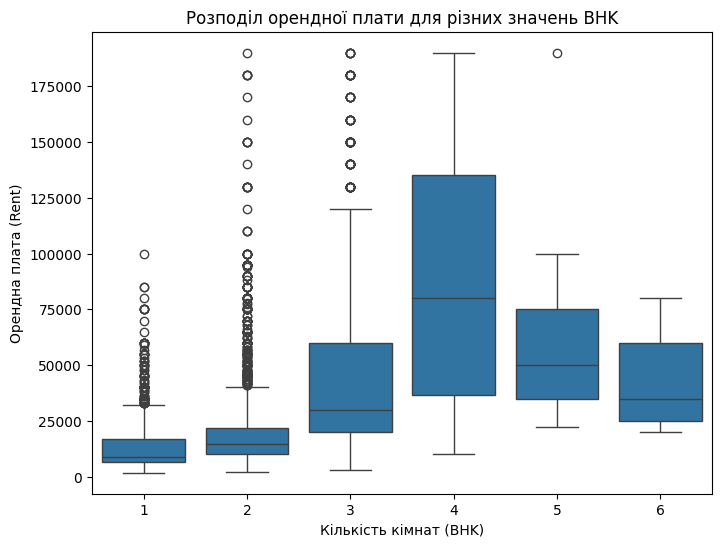

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df_clean['BHK'],
    y=df_clean['Rent']
)

plt.title('Розподіл орендної плати для різних значень BHK')
plt.xlabel('Кількість кімнат (BHK)')
plt.ylabel('Орендна плата (Rent)')

plt.show()

Було побудовано boxplot для аналізу взаємозв’язку між кількістю кімнат (BHK)
та орендною платою (Rent).

З графіка видно, що зі збільшенням кількості кімнат
медіанне значення орендної плати зростає:
квартири з більшою кількістю кімнат зазвичай коштують дорожче.

Також помітно, що зі збільшенням BHK зростає розкид значень,
що означає більшу варіативність цін для великих квартир.

Для деяких значень BHK (особливо 2–4) присутні викиди,
що може свідчити про елітні або нетипові об’єкти.

Загалом, BHK є важливою ознакою, яка впливає на орендну плату.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


1. 1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding.

In [21]:
# Обираємо категоріальні колонки з невеликою кількістю значень
cat_cols = ['Area Type', 'Furnishing Status', 'Tenant Preferred']

# One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Перевіряємо результат
df_encoded.shape
df_encoded.head()

,Posted On,BHK,Rent,Size,Floor,Area Locality,City,Bathroom,Point of Contact,log_rent,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family
0,2022-05-18,2,10000,1100,Ground out of 2,Bandel,Kolkata,2,Contact Owner,9.210440,False,True,False,True,True,False
1,2022-05-13,2,20000,800,1 out of 3,"Phool Bagan, Kankurgachi",Kolkata,1,Contact Owner,9.903538,False,True,True,False,True,False
2,2022-05-16,2,17000,1000,1 out of 3,Salt Lake City Sector 2,Kolkata,1,Contact Owner,9.741027,False,True,True,False,True,False
3,2022-07-04,2,10000,800,1 out of 2,Dumdum Park,Kolkata,1,Contact Owner,9.210440,False,True,False,True,True,False
4,2022-05-09,2,7500,850,1 out of 2,South Dum Dum,Kolkata,1,Contact Owner,8.922792,True,False,False,True,False,False


2. Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі

In [22]:
# Ціна за квадратний метр
df_encoded['price_per_sqft'] = df_encoded['Rent'] / df_encoded['Size']

# Кількість кімнат на ванну
df_encoded['rooms_per_bathroom'] = df_encoded['BHK'] / df_encoded['Bathroom']

df_encoded[['price_per_sqft', 'rooms_per_bathroom']].head()

,price_per_sqft,rooms_per_bathroom
0,9.090909,1.0
1,25.000000,2.0
2,17.000000,2.0
3,12.500000,2.0
4,8.823529,2.0


3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.

In [23]:
cols_to_drop = [
    'Posted On',
    'Floor',
    'Area Locality',
    'City',
    'Point of Contact'
]

df_model = df_encoded.drop(columns=cols_to_drop)

df_model.shape

(4630, 13)

Було видалено колонки, які:
- мають текстовий формат
- містять забагато унікальних значень
- не несуть корисної інформації для моделі

Це дозволяє уникнути шуму та покращити якість навчання моделі.

4. Розділіть дані на ознаки (X) та цільову змінну (y)

In [24]:
X = df_model.drop(columns=['Rent'])
y = df_model['Rent']

print(X.shape)
print(y.shape)

(4630, 12)
(4630,)


Дані було розділено на:
- X — набір ознак (всі змінні, крім цільової)
- y — цільова змінна (Rent)

Це необхідно для подальшого навчання моделі.

5. Застосуйте стандартизацію до числових ознак

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.05509642,  0.29953912,  0.10756117, -0.71853989, -0.94985187,
         0.95067497, -0.94820758,  1.25445288,  0.6114632 , -0.328916  ,
        -0.51210091, -0.33402516],
       [-0.05509642, -0.22965501, -1.1281912 ,  0.11011652, -0.94985187,
         0.95067497,  1.05462139, -0.79716027,  0.6114632 , -0.328916  ,
        -0.21284385,  2.34140107],
       [-0.05509642,  0.12314107, -1.1281912 , -0.08417808, -0.94985187,
         0.95067497,  1.05462139, -0.79716027,  0.6114632 , -0.328916  ,
        -0.3633274 ,  2.34140107],
       [-0.05509642, -0.22965501, -1.1281912 , -0.71853989, -0.94985187,
         0.95067497, -0.94820758,  1.25445288,  0.6114632 , -0.328916  ,
        -0.4479744 ,  2.34140107],
       [-0.05509642, -0.14145599, -1.1281912 , -1.06244834,  1.05279574,
        -1.05188422, -0.94820758,  1.25445288, -1.63542141, -0.328916  ,
        -0.51713044,  2.34140107]])

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)
print("Розмір y_train:", y_train.shape)
print("Розмір y_test:", y_test.shape)

Розмір X_train: (3704, 12)
Розмір X_test: (926, 12)
Розмір y_train: (3704,)
Розмір y_test: (926,)


2. Створіть модель лінійної регресії.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model

LinearRegression()

3. Навчіть модель на навчальних даних.

In [28]:
model.fit(X_train, y_train)

LinearRegression()

4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.

In [29]:
for feature, weight in zip(X.columns, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

BHK: -11467.41
Size: 2754.20
Bathroom: 10877.95
log_rent: 24466.27
Area Type_Carpet Area: -1469.96
Area Type_Super Area: -2253.94
Furnishing Status_Semi-Furnished: -175.88
Furnishing Status_Unfurnished: 900.11
Tenant Preferred_Bachelors/Family: 1275.98
Tenant Preferred_Family: 371.25
price_per_sqft: 3364.63
rooms_per_bathroom: 6438.43

Зміщення (intercept): 26971.22


Найбільший вплив на прогноз мають ознаки:
- log_rent
- BHK

Оскільки вони мають найбільші за модулем коефіцієнти, це означає,
що саме ці змінні найбільше впливають на орендну плату.

Зокрема, log_rent має сильний позитивний вплив, тоді як BHK має значний негативний вплив на прогноз.

5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [30]:
# Прогнози на навчальній вибірці
y_train_pred = model.predict(X_train)

# Прогнози на тестовій вибірці
y_test_pred = model.predict(X_test)

# Порівняння перших 10 прогнозів з реальними значеннями
comparison = pd.DataFrame({
    'Реальна орендна плата': y_test.values[:10],
    'Прогнозована орендна плата': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})

print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна орендна плата  Прогнозована орендна плата  Помилка
0                  75000                     71830.0   3170.0
1                  38000                     60813.0 -22813.0
2                  38000                     41992.0  -3992.0
3                   5250                    -11830.0  17080.0
4                   5000                    -12208.0  17208.0
5                  20000                     28128.0  -8128.0
6                  13000                     12650.0    350.0
7                  14000                     18822.0  -4822.0
8                  13000                     18357.0  -5357.0
9                  15000                     17200.0  -2200.0


Було побудовано прогнози для навчальної та тестової вибірок за допомогою моделі лінійної регресії.

Для оцінки якості моделі було порівняно перші 10 прогнозів на тестовій вибірці з реальними значеннями орендної плати.

Результати показують, що модель допускає значні помилки: у деяких випадках прогноз суттєво відрізняється від реального значення, а іноді навіть набуває від’ємних значень, що є некоректним для орендної плати.

Це свідчить про те, що модель не є достатньо точною та потребує покращення (наприклад, додавання нових ознак або використання більш складних моделей).

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Метрики на тестовій вибірці
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

# Метрики на тренувальній вибірці
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ")
print("="*50)

print("\nТестова вибірка:")
print(f"MAE: {mae_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²: {r2_test:.3f}")

print("\nТренувальна вибірка:")
print(f"MAE: {mae_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ

Тестова вибірка:
MAE: 9602.52
RMSE: 14808.04
R²: 0.797

Тренувальна вибірка:
MAE: 9146.22
RMSE: 13391.36
R²: 0.798


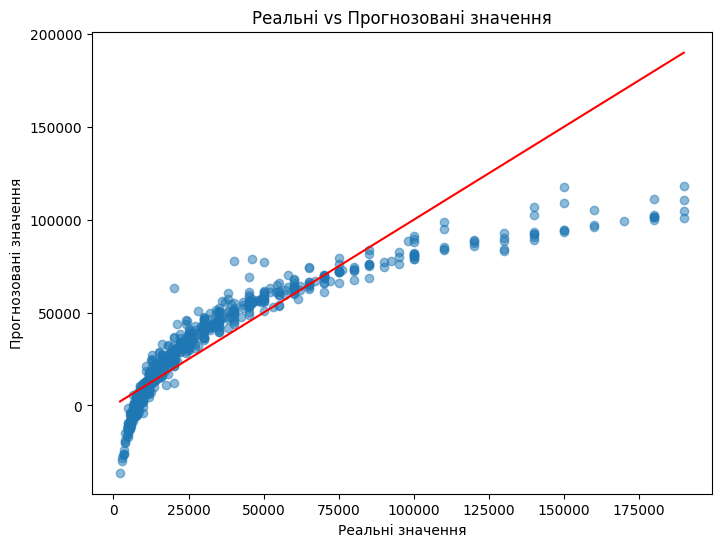

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.xlabel('Реальні значення')
plt.ylabel('Прогнозовані значення')
plt.title('Реальні vs Прогнозовані значення')

# ідеальна лінія (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

Графік "реальні vs прогнозовані значення" показує, що модель має низьку точність.

Ідеально точки мали б лежати вздовж діагональної лінії (y = x), однак у даному випадку вони значно відхиляються від неї.

Помітно, що:
- для малих значень модель часто недооцінює або навіть дає від’ємні прогнози
- для великих значень модель систематично недооцінює реальні значення

Це означає, що модель не здатна коректно відтворити залежність у даних.

Разом із низьким значенням R² та високими помилками це підтверджує, що модель має ознаки недонавчання.

Отже, лінійна регресія є недостатньо ефективною для цієї задачі та потребує покращення.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

1. Обчисліть помилки (residuals = реальні - прогнозовані значення)

In [33]:
residuals = y_test - y_test_pred

residuals[:10]

,Rent
830,3169.563484
2437,-22813.113410
4018,-3991.797267
3271,17080.487961
33,17208.353839
3226,-8127.912106
2473,350.315540
1941,-4821.999416
1603,-5357.234510
179,-2200.063077


2. Побудуйте гістограму розподілу помилок

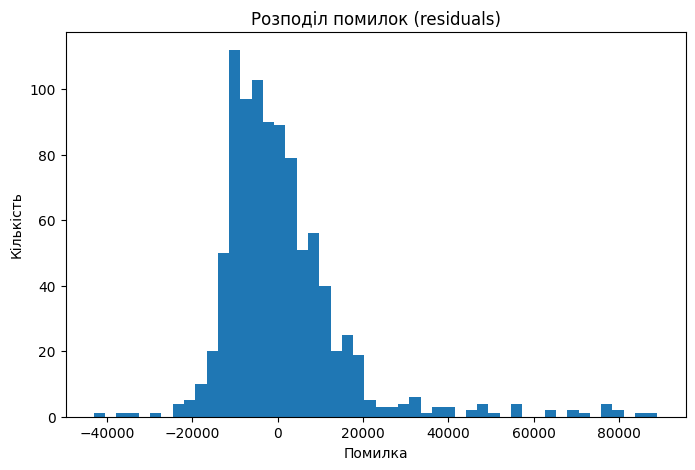

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Розподіл помилок (residuals)")
plt.xlabel("Помилка")
plt.ylabel("Кількість")
plt.show()

Висновок до гістограми:

Помилки розподілені нерівномірно та несиметрично.
Є великі відхилення і викиди, особливо в позитивну сторону.

Модель іноді дає значні помилки, тому її точність невисока.

3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?

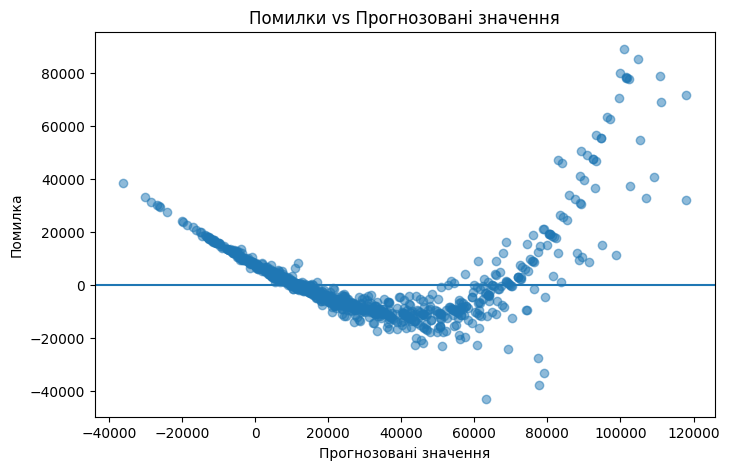

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(y_test_pred, residuals, alpha=0.5)

plt.axhline(y=0)  # линия нулевой ошибки

plt.title("Помилки vs Прогнозовані значення")
plt.xlabel("Прогнозовані значення")
plt.ylabel("Помилка")

plt.show()

Висновок до scatter plot:

Помилка зростає зі збільшенням прогнозованого значення.

Також спостерігається нелінійна залежність (U-подібна форма),
що означає, що лінійна модель погано описує дані.

Модель працює гірше для малих і великих значень.

4. Знайдіть 5 прогнозів з найбільшими помилками

In [39]:
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(residuals)
}, index=y_test.index)

# Топ-5 найбільших помилок
top_errors = errors_df.nlargest(5, 'error')

print("Об’єкти з найбільшими помилками прогнозування:")
print(top_errors)
print(top_errors)

Об’єкти з найбільшими помилками прогнозування:
        real      predicted         error
858   190000  100941.822843  89058.177157
1004  190000  104690.821522  85309.178478
1161  180000   99879.602188  80120.397812
780   190000  110876.769555  79123.230445
1247  180000  101554.804170  78445.195830
        real      predicted         error
858   190000  100941.822843  89058.177157
1004  190000  104690.821522  85309.178478
1161  180000   99879.602188  80120.397812
780   190000  110876.769555  79123.230445
1247  180000  101554.804170  78445.195830


Модель найбільше помиляється на дорогих об’єктах.

Вона суттєво недооцінює їхню вартість, що свідчить
про нестачу важливих ознак у даних.

5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.

Кількість кімнат:

In [41]:
errors_df = pd.DataFrame({
    'real': y_test,
    'predicted': y_test_pred,
    'error': abs(residuals)
})

errors_df['BHK'] = df_model.loc[y_test.index, 'BHK']

bhk_error = errors_df.groupby('BHK')['error'].mean().sort_values(ascending=False)

bhk_error

,error
BHK,
5,27440.660701
4,23602.954786
3,13302.004729
1,9901.939863
2,6507.369560
6,4421.975228


Спостерігається зростання помилки зі збільшенням кількості кімнат (BHK).
Найбільші помилки для 4–5 кімнатних квартир.

Ймовірно, модель не враховує фактори, які впливають на дороге житло (локація, стан, престижність району).

Місто:

In [43]:
errors_df['City'] = df_encoded.loc[y_test.index, 'City']

city_error = errors_df.groupby('City')['error'].mean().sort_values(ascending=False)

city_error.head(10)

,error
City,
Mumbai,16113.334077
Kolkata,9344.878559
Delhi,8613.174925
Bangalore,8426.912863
Chennai,7262.120638
Hyderabad,6867.161809


Помилка суттєво відрізняється між містами, що свідчить про нерівномірну якість моделі.

Найгірші результати у Mumbai, що може бути пов’язано з більш складним ринком нерухомості або відсутністю ознак, які описують престижність районів, інфраструктуру тощо.

6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

Щоб покращити якість моделі, я б зробила такі кроки:

1. Додала б більше корисних ознак, наприклад район, стан житла або близькість до транспорту.
2. Використала б City як ознаку, бо ціни на оренду можуть сильно відрізнятися між містами.
3. Спробувала б інші моделі.
4. Продовжила б аналіз викидів, бо модель найбільше помиляється на дорогих об’єктах.

Додатково я вирішила спробувати додати City до моделі, щоб перевірити, чи покращиться якість прогнозу.

In [44]:
cat_cols = ['Area Type', 'Furnishing Status', 'Tenant Preferred', 'City']

df_encoded_test = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

df_encoded_test.head()

,Posted On,BHK,Rent,Size,Floor,Area Locality,Bathroom,Point of Contact,log_rent,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,2022-05-18,2,10000,1100,Ground out of 2,Bandel,2,Contact Owner,9.210440,False,True,False,True,True,False,False,False,False,True,False
1,2022-05-13,2,20000,800,1 out of 3,"Phool Bagan, Kankurgachi",1,Contact Owner,9.903538,False,True,True,False,True,False,False,False,False,True,False
2,2022-05-16,2,17000,1000,1 out of 3,Salt Lake City Sector 2,1,Contact Owner,9.741027,False,True,True,False,True,False,False,False,False,True,False
3,2022-07-04,2,10000,800,1 out of 2,Dumdum Park,1,Contact Owner,9.210440,False,True,False,True,True,False,False,False,False,True,False
4,2022-05-09,2,7500,850,1 out of 2,South Dum Dum,1,Contact Owner,8.922792,True,False,False,True,False,False,False,False,False,True,False


Після кодування City з’явились нові ознаки, які дозволяють моделі враховувати різницю між містами.